In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

create a seed to generate test data with.

In [ ]:
def generate_data(num_samples=2048, seq_len=32, d_model=64):
    X = torch.randn(num_samples, seq_len, d_model)
    y = X.mean(dim=1)
    return X, y


Create test data for sampling. This generated data set is consistent for testing and helps to make outcomes deterministic. 

In [4]:
class StandardMHA(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def forward(self, x):
        out, _ = self.mha(x, x, x)
        return out

Creation of the neural network module with self.attn creating multi-head self-attention. self.fc makes it so the model doesn't only use attention. forward makes use of queries, keys, and values.

In [5]:
class QuantizedMHA(nn.Module):
    def __init__(self, d_model, num_heads, bits=8):
        super().__init__()
        self.bits = bits
        self.mha = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def fake_quant(self, x):
        qmax = 2 ** (self.bits - 1) - 1
        scale = x.abs().max() / qmax + 1e-8
        return torch.round(x / scale).clamp(-qmax, qmax) * scale

    def forward(self, x):
        xq = self.fake_quant(x)
        out, _ = self.mha(xq, xq, xq)
        return out

Quantized model for testing

In [6]:
class SparseMHA(nn.Module):
    def __init__(self, d_model, num_heads, window=8):
        super().__init__()
        self.window = window
        self.mha = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def forward(self, x):
        T = x.size(1)
        mask = torch.ones(T, T, device=x.device)
        for i in range(T):
            mask[i, max(0, i-self.window): i+self.window] = 0
        mask = mask.bool()
        out, _ = self.mha(x, x, x, attn_mask=mask)
        return out

Sparse model for testing

In [7]:
class RandomPositionalMHA(nn.Module):
    def __init__(self, d_model, num_heads, max_shift=4):
        super().__init__()
        self.max_shift = max_shift
        self.mha = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def forward(self, x):
        B = x.size(0)
        shifts = torch.randint(-self.max_shift, self.max_shift+1, (B,), device=x.device)
        x_shifted = torch.stack([torch.roll(x[b], shifts=int(shifts[b]), dims=0) for b in range(B)])
        out, _ = self.mha(x_shifted, x_shifted, x_shifted)
        return out

Random positional model for testing

In [8]:
class AttentionModel(nn.Module):
    def __init__(self, d_model, attn_module):
        super().__init__()
        self.attn = attn_module
        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        attn_out = self.attn(x)
        pooled = attn_out.mean(dim=1)
        return self.fc(pooled)

Attention model for transformers

In [9]:
def make_model(attn_type, d_model, num_heads):
    if attn_type == "standard":
        attn = StandardMHA(d_model, num_heads)
    elif attn_type == "quantized":
        attn = QuantizedMHA(d_model, num_heads)
    elif attn_type == "sparse":
        attn = SparseMHA(d_model, num_heads)
    elif attn_type == "random_pos":
        attn = RandomPositionalMHA(d_model, num_heads)
    else:
        raise ValueError("Unknown attention type")
    return AttentionModel(d_model, attn)

Generate and activate the models

In [10]:
def train_and_profile(attn_type, num_heads, X, y, epochs=10, runs=1):
    total_times = []
    forward_times = []
    peak_memories = []
    loss_curves = []
    accuracy_curves = []  # NEW: track R²

    for _ in range(runs):
        model = make_model(attn_type, X.shape[-1], num_heads).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.MSELoss()

        Xd, yd = X.to(device), y.to(device)
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

        run_fwd = []
        run_losses = []
        run_acc = []  # NEW

        start_train = time.time()

        for _ in range(epochs):
            start_fwd = time.time()
            preds = model(Xd)
            if device.type == "cuda":
                torch.cuda.synchronize()
            run_fwd.append(time.time() - start_fwd)

            loss = criterion(preds, yd)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            run_losses.append(loss.item())

            with torch.no_grad():
                preds_cpu = preds.cpu().numpy()
                yd_cpu = yd.cpu().numpy()
                acc = r2_score(yd_cpu, preds_cpu)
                run_acc.append(acc)

        total_times.append(time.time() - start_train)
        forward_times.append(np.mean(run_fwd))
        loss_curves.append((np.cumsum(run_fwd), run_losses))
        accuracy_curves.append((np.cumsum(run_fwd), run_acc))  # NEW

        if device.type == "cuda":
            peak_memories.append(torch.cuda.max_memory_allocated() / 1024**2)

    return {
        "mean_forward_time": np.mean(forward_times),
        "mean_total_time": np.mean(total_times),
        "mean_peak_memory": np.mean(peak_memories) if peak_memories else None,
        "loss_curves": loss_curves,
        "accuracy_curves": accuracy_curves  # NEW
    }


Training cell for module that records statistics for graphing

In [11]:
def validate_attention_shapes():
    X, _ = generate_data(num_samples=8, seq_len=16, d_model=64)
    X = X.to(device)

    for attn in ["standard", "quantized", "sparse", "random_pos"]:
        for h in [2, 4, 8]:
            model = make_model(attn, 64, h).to(device)
            with torch.no_grad():
                out = model.attn(X)
            assert out.shape == X.shape, f"{attn}, heads={h} shape mismatch"

    print("✅ Shape validation passed")

validate_attention_shapes()


✅ Shape validation passed


Shape validation to ensure each model to ensure they work

In [12]:
for attn in ["standard", "quantized", "sparse", "random_pos"]:
    X, y = generate_data(num_samples=512)
    result = train_and_profile(attn, 4, X, y, epochs=10, runs=1)
    losses = result["loss_curves"][0][1]
    print(f"{attn}: {losses[0]:.4f} → {losses[-1]:.4f}")
    assert losses[-1] < losses[0], "Loss did not decrease!"
    print("✅ Learning OK\n")


standard: 0.0380 → 0.0318
✅ Learning OK

quantized: 0.0387 → 0.0324
✅ Learning OK

sparse: 0.0388 → 0.0325
✅ Learning OK

random_pos: 0.0383 → 0.0319
✅ Learning OK



Checks to ensure each model is learning or not

In [13]:
model = make_model("standard", 64, 8).to(device)
X, y = generate_data(num_samples=32)
Xd, yd = X.to(device), y.to(device)
loss = nn.MSELoss()(model(Xd), yd)
loss.backward()
grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
print("Gradient norm:", grad_norm)
assert grad_norm > 0
print("✅ Gradients flowing")

Gradient norm: 0.05439029913395643
✅ Gradients flowing


Gradient flow check

In [14]:
X, y = generate_data(num_samples=1024)

attn_types = ["standard", "quantized", "sparse", "random_pos"]
head_counts = [2, 4, 8, 16]
epoch_counts = [10, 100, 1000]

results_epochs = {}

for epochs in epoch_counts:
    print(f"\n=== Running for {epochs} epochs ===")
    results_epochs[epochs] = {}
    for attn in attn_types:
        results_epochs[epochs][attn] = {}
        for h in head_counts:
            print(f"{attn} | {h} heads")
            results_epochs[epochs][attn][h] = train_and_profile(
                attn_type=attn,
                num_heads=h,
                X=X,
                y=y,
                epochs=epochs,
                runs=3
            )



=== Running for 10 epochs ===
standard | 2 heads
standard | 4 heads
standard | 8 heads
standard | 16 heads
quantized | 2 heads
quantized | 4 heads
quantized | 8 heads
quantized | 16 heads
sparse | 2 heads
sparse | 4 heads
sparse | 8 heads
sparse | 16 heads
random_pos | 2 heads
random_pos | 4 heads
random_pos | 8 heads
random_pos | 16 heads

=== Running for 100 epochs ===
standard | 2 heads
standard | 4 heads
standard | 8 heads
standard | 16 heads
quantized | 2 heads
quantized | 4 heads
quantized | 8 heads
quantized | 16 heads
sparse | 2 heads
sparse | 4 heads
sparse | 8 heads
sparse | 16 heads
random_pos | 2 heads
random_pos | 4 heads
random_pos | 8 heads
random_pos | 16 heads

=== Running for 1000 epochs ===
standard | 2 heads
standard | 4 heads
standard | 8 heads
standard | 16 heads
quantized | 2 heads
quantized | 4 heads
quantized | 8 heads
quantized | 16 heads
sparse | 2 heads
sparse | 4 heads
sparse | 8 heads
sparse | 16 heads
random_pos | 2 heads
random_pos | 4 heads
random_pos 

Run 2 to 16 heads for 10, 100, and 1000 epochs for each model.

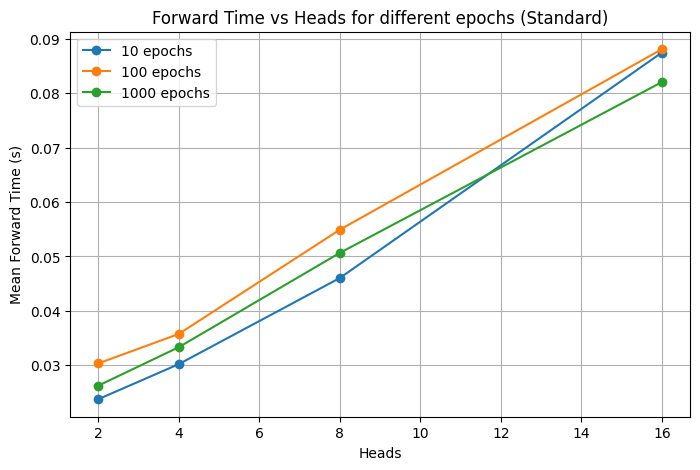

In [15]:
plt.figure(figsize=(8,5))
for epochs in epoch_counts:
    fwd_times = [results_epochs[epochs]["standard"][h]["mean_forward_time"] for h in head_counts]
    plt.plot(head_counts, fwd_times, marker="o", label=f"{epochs} epochs")
plt.xlabel("Heads")
plt.ylabel("Mean Forward Time (s)")
plt.title("Forward Time vs Heads for different epochs (Standard)")
plt.legend()
plt.grid(True)
plt.show()


Plot statistics for forward time of standard model

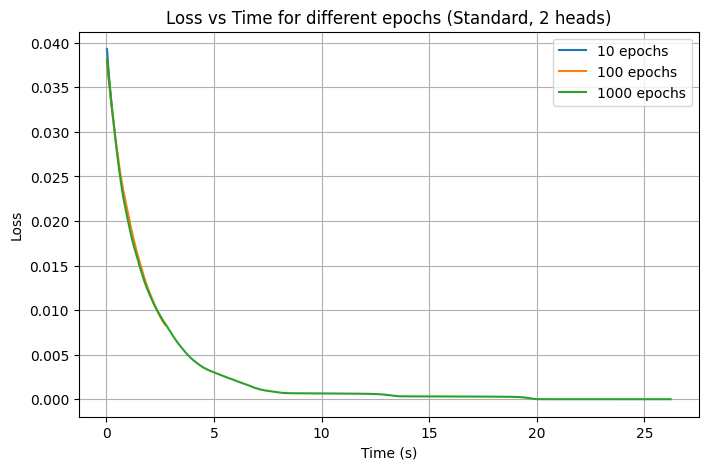

In [16]:
plt.figure(figsize=(8,5))
for epochs in epoch_counts:
    t, l = results_epochs[epochs]["standard"][head_counts[0]]["loss_curves"][0]
    plt.plot(t, l, label=f"{epochs} epochs")
plt.xlabel("Time (s)")
plt.ylabel("Loss")
plt.title(f"Loss vs Time for different epochs (Standard, {head_counts[0]} heads)")
plt.legend()
plt.grid(True)
plt.show()

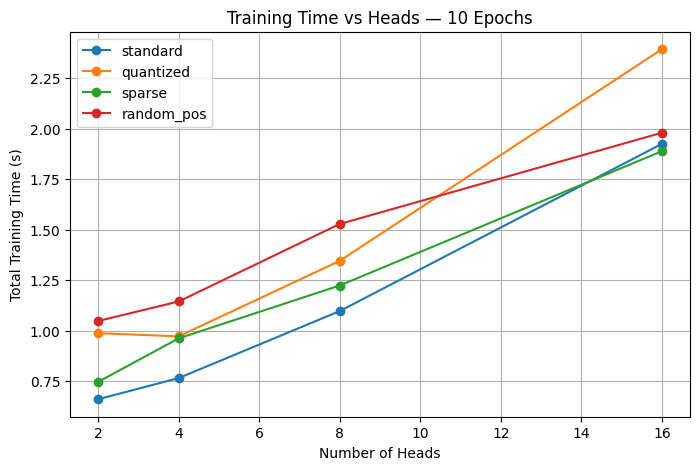

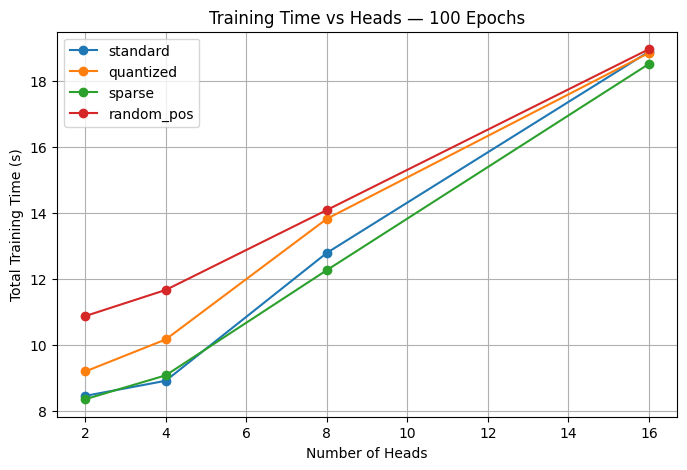

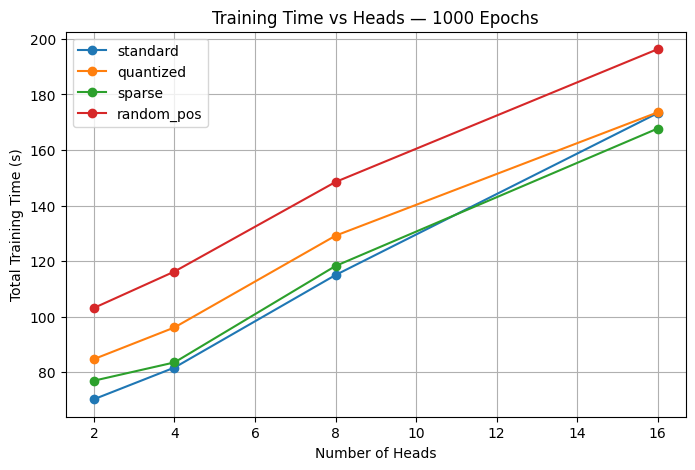

In [17]:
for epochs in epoch_counts:
    plt.figure(figsize=(8,5))
    for attn in attn_types:
        times = [results_epochs[epochs][attn][h]["mean_total_time"] for h in head_counts]
        plt.plot(head_counts, times, marker="o", label=attn)
    plt.xlabel("Number of Heads")
    plt.ylabel("Total Training Time (s)")
    plt.title(f"Training Time vs Heads — {epochs} Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()


Generate the graphs of all the models with each graph focusing on a different number of epochs.

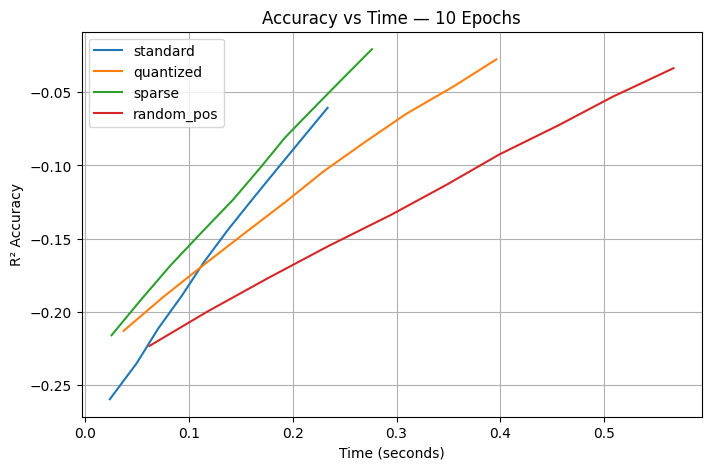

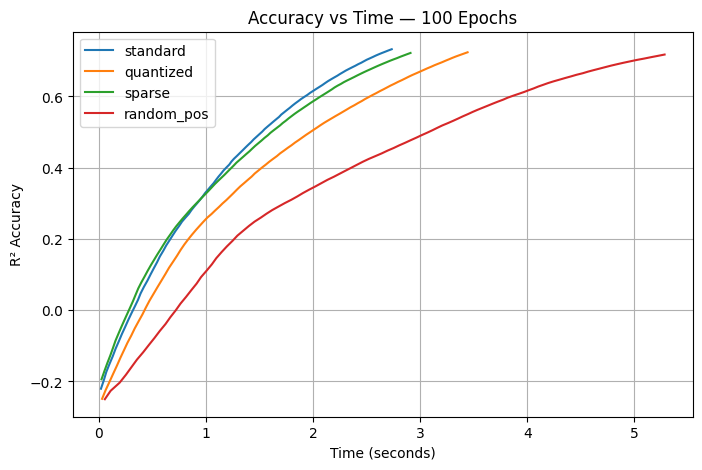

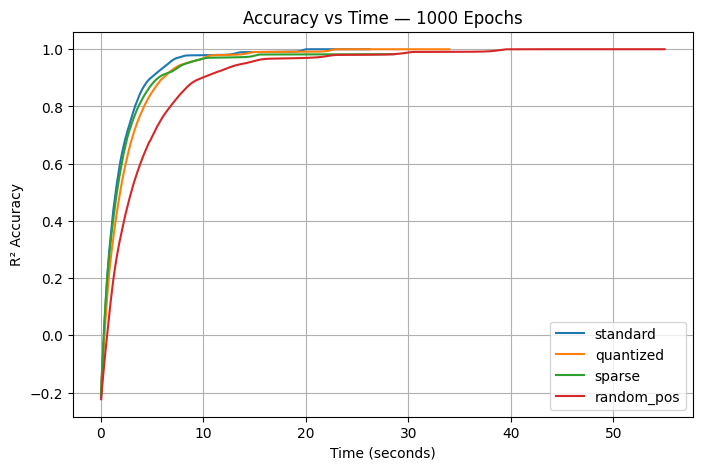

In [18]:
for epochs in epoch_counts:
    plt.figure(figsize=(8,5))
    for attn in attn_types:
        times, accs = results_epochs[epochs][attn][head_counts[0]]["accuracy_curves"][0]
        plt.plot(times, accs, label=attn)
    plt.xlabel("Time (seconds)")
    plt.ylabel("R² Accuracy")
    plt.title(f"Accuracy vs Time — {epochs} Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()


Graph accuracy vs time for each model with each graph representing different number of epochs.

In [19]:
if device.type == "cuda":
    plt.figure(figsize=(8,5))
    for attn in attn_types:
        mems = [results_epochs[1000][attn][h]["mean_peak_memory"] for h in head_counts]
        plt.plot(head_counts, mems, marker="o", label=attn)
    plt.xlabel("Heads")
    plt.ylabel("Peak GPU Memory (MB)")
    plt.title("Peak Memory vs Heads (1000 epochs)")
    plt.legend()
    plt.grid(True)
    plt.show()


If system used GPU graph the peak gpu memory used for 1000 epochs

In [20]:
def visualize_attention(attn_type, num_heads=4, X=None, epoch_label=""):
    if X is None:
        X, _ = generate_data(num_samples=1, seq_len=16, d_model=64)
    X = X.to(device)
    
    # Create module to grab weights
    if attn_type == "standard":
        attn = nn.MultiheadAttention(X.shape[-1], num_heads, batch_first=True)
    elif attn_type == "quantized":
        attn = QuantizedMHA(X.shape[-1], num_heads)
    elif attn_type == "sparse":
        attn = SparseMHA(X.shape[-1], num_heads, window=4)
    elif attn_type == "random_pos":
        attn = RandomPositionalMHA(X.shape[-1], num_heads)
    else:
        raise ValueError("Unknown attention type")
    
    attn = attn.to(device)
    attn.eval()
    
    attn_weights = None
    def hook(module, input, output):
        nonlocal attn_weights
        if isinstance(module, nn.MultiheadAttention):
            attn_weights = output[1]

    if isinstance(attn, nn.MultiheadAttention):
        attn.register_forward_hook(hook)
        with torch.no_grad():
            _ = attn(X)
    else:
        mha_module = attn.mha if hasattr(attn, "mha") else attn.attn.mha
        mha_module.register_forward_hook(hook)
        with torch.no_grad():
            _ = attn(X)
    
    if attn_weights is None:
        print("Could not extract attention weights.")
        return
    
    weights = attn_weights[0].cpu().detach().numpy()
    if weights.ndim == 3:
        weights = weights[0]

    plt.figure(figsize=(6,5))
    sns.heatmap(weights, cmap="viridis", annot=False)
    plt.title(f"Attention Map: {attn_type} ({num_heads} heads) {epoch_label}")
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.show()

In [21]:
X_vis, _ = generate_data(num_samples=1, seq_len=16, d_model=64)
for attn in ["standard", "quantized", "sparse", "random_pos"]:
    visualize_attention(attn, num_heads=4, X=X_vis, epoch_label="example")

TypeError: MultiheadAttention.forward() missing 2 required positional arguments: 'key' and 'value'